In [3]:
from pathlib import Path

project_root = Path.cwd().resolve()
while project_root != project_root.parent and not (project_root / "pyproject.toml").exists():
    project_root = project_root.parent

%cd {project_root}

/hfm/songlin/psi


/hfm/songlin/psi/.venv-psi/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [5]:
import torch
import numpy as np
from pathlib import Path
from psi.utils import parse_args_to_tyro_config, seed_everything, move_to_device, batchify
from psi.config.config import LaunchConfig

In [6]:
ckpt_step = 40000
run_dir = Path(".runs/finetune/g1wholebodylocomotionpickbetweentablesvariant5-v0.simple.flow1000.cosine.lr1.0e-04.b128.gpus8.2603111837")
config_:LaunchConfig = parse_args_to_tyro_config(run_dir / "argv.txt") # type: ignore
conf = (run_dir / "run_config.json").open("r").read()
launch_config = config_.model_validate_json(conf)

In [8]:
seed_everything(launch_config.seed or 42)

In [11]:
device = "cuda:0"

In [13]:
from psi.models.psi0 import Psi0Model 
psi0 = Psi0Model.from_pretrained(run_dir, ckpt_step, launch_config, device=device)
psi0.to(device)
psi0.eval()
print("Model loaded successfully.")

[05:11:04 03/12] INFO     | >> [*] Resized model token embeddings to 153792                            ]8;id=74057;file:///hfm/songlin/psi/src/psi/models/psi0.py\psi0.py]8;;\:]8;id=751593;file:///hfm/songlin/psi/src/psi/models/psi0.py#1550\1550]8;;\

                 INFO     | >> [*] loaded vlm_backbone checkpoint successfully.                        ]8;id=258653;file:///hfm/songlin/psi/src/psi/models/psi0.py\psi0.py]8;;\:]8;id=805724;file:///hfm/songlin/psi/src/psi/models/psi0.py#1553\1553]8;;\

[05:11:07 03/12] INFO     | >> [*] Total ActionTransformerModel parameters: 497,719,256                ]8;id=362671;file:///hfm/songlin/psi/src/psi/models/psi0.py\psi0.py]8;;\:]8;id=29735;file:///hfm/songlin/psi/src/psi/models/psi0.py#1510\1510]8;;\

                 INFO     | >> [*] Total VLM Backbone parameters: 2,131,333,120                        ]8;id=746930;file:///hfm/songlin/psi/src/psi/models/psi0.py\psi0.py]8;;\:]8;id=373783;file:///hfm/songlin/psi/src/psi/models/psi0.py#1514\1514]8;;\

                 INFO     | >> [*] loaded action head checkpoint successfully.                         ]8;id=965939;file:///hfm/songlin/psi/src/psi/models/psi0.py\psi0.py]8;;\:]8;id=831009;file:///hfm/songlin/psi/src/psi/models/psi0.py#1571\1571]8;;\

Model loaded successfully.


In [15]:
from psi.config.data_lerobot import LerobotDataConfig
data_cfg: LerobotDataConfig = launch_config.data # type: ignore

from psi.config.model_psi0 import Psi0ModelConfig
model_cfg: Psi0ModelConfig = launch_config.model # type: ignore

In [35]:
maxmin = data_cfg.transform.field

In [16]:
transform_kwargs=dict(
    vlm_processor=psi0.vlm_processor,
)

In [17]:
dataset = data_cfg(split="train", transform_kwargs=transform_kwargs)

In [21]:
dataset.raw_dataset.meta

LeRobotDatasetMetadata({
    Repository ID: 'G1WholebodyLocomotionPickBetweenTablesVariant5-v0',
    Total episodes: '100',
    Total frames: '50206',
    Features: '['observation.images.egocentric', 'observation.hand_joints', 'observation.arm_joints', 'observation.leg_joints', 'observation.prev_torso_rpy', 'observation.prev_height', 'states', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'next.done', 'task_index']',
})',

In [24]:
eps_idx = np.random.randint(0, dataset.raw_dataset.meta.total_episodes)
print(eps_idx)

65


In [ ]:
start_frame_idx = dataset.raw_dataset.base_dataset.episode_data_index["from"][eps_idx].item()
end_frame_idx = dataset.raw_dataset.base_dataset.episode_data_index["to"][eps_idx].item()

In [27]:
print(start_frame_idx, end_frame_idx)
print("num frames in this episode:", end_frame_idx - start_frame_idx)

32674 33175
num frames in this episode: 501


In [68]:
avg_action_errors_denormed_list = []

labels_denormed = [
    "hand_joints",
    "arm_joints",
    "rpy", # torso rpy
    "height",
    "vx",
    "vy",
    "torso_vyaw",
    "target_yaw",
]

stride = 4
for i in range(start_frame_idx, end_frame_idx, stride):
    frame = dataset[i]
    # print(list(frame.keys()))
    images = frame["raw_images"]
    batch_images = [images] # List[List[PIL.Image.Image]] batch size == 1
    instruction = frame['instruction']
    batch_instructions = [instruction] # List[str]

    states = frame['states'] # (1, 15)
    batch_states = torch.from_numpy(states).unsqueeze(0).to(device) # (B, H, D)

    pred_actions = psi0.predict_action(
        observations=batch_images, 
        states=batch_states, 
        instructions=batch_instructions, 
        num_inference_steps=10, 
        traj2ds=None)
    
    gt_action = torch.from_numpy(frame["raw_actions"]).unsqueeze(0).to(device) # (1, Tp, Da)

    print("gt_action shape:", gt_action.shape, "pred_actions shape:", pred_actions.shape)
    denormalized_pred_actions = maxmin.denormalize(pred_actions)

    error = denormalized_pred_actions - gt_action # (1, Tp, Da)
    print("error shape:", error.shape)
    error_l1 = error.detach().abs().cpu().numpy().reshape(-1, 36)
    print("error_l1 shape:", error_l1.shape)

    # print(denormalized_pred_actions.shape)
    # break

    avg_action_errors_denormed = error_l1.mean(0)
    print("avg_action_errors_denormed shape:", avg_action_errors_denormed.shape)
    # break
    # print(avg_action_errors_denormed.shape)

    # avg_lr_action_err_denormed = np.split(
    #     avg_action_errors_denormed, [14, 28, 31, 32, 33, 34, 35], axis=-1
    # )
    avg_action_errors_denormed_list.append(avg_action_errors_denormed)

    #  # log metrics
    # for i in range(len(avg_lr_action_err_denormed)):
    #     print(f"denormed_err_l1_{labels_denormed[i]}: {np.linalg.norm(avg_lr_action_err_denormed[i])}")

    # break

avg_action_errors_denormed_list = np.stack(avg_action_errors_denormed_list, axis=0)
print("avg_action_errors_denormed_list shape:", avg_action_errors_denormed_list.shape)
avg_action_errors_denormed = avg_action_errors_denormed_list.mean(axis=0)

avg_action_errors_denormed_split = np.split(
    avg_action_errors_denormed, [14, 28, 31, 32, 33, 34, 35], axis=-1
)

print("\n---------------------------\n")
for i in range(len(avg_action_errors_denormed_split)):
    print(f"denormed_err_l1_{labels_denormed[i]}: {np.linalg.norm(avg_action_errors_denormed_split[i])}")


gt_action shape: torch.Size([1, 30, 36]) pred_actions shape: torch.Size([1, 30, 36])
error shape: torch.Size([1, 30, 36])
error_l1 shape: (30, 36)
avg_action_errors_denormed shape: (36,)
gt_action shape: torch.Size([1, 30, 36]) pred_actions shape: torch.Size([1, 30, 36])
error shape: torch.Size([1, 30, 36])
error_l1 shape: (30, 36)
avg_action_errors_denormed shape: (36,)
gt_action shape: torch.Size([1, 30, 36]) pred_actions shape: torch.Size([1, 30, 36])
error shape: torch.Size([1, 30, 36])
error_l1 shape: (30, 36)
avg_action_errors_denormed shape: (36,)
gt_action shape: torch.Size([1, 30, 36]) pred_actions shape: torch.Size([1, 30, 36])
error shape: torch.Size([1, 30, 36])
error_l1 shape: (30, 36)
avg_action_errors_denormed shape: (36,)
gt_action shape: torch.Size([1, 30, 36]) pred_actions shape: torch.Size([1, 30, 36])
error shape: torch.Size([1, 30, 36])
error_l1 shape: (30, 36)
avg_action_errors_denormed shape: (36,)
gt_action shape: torch.Size([1, 30, 36]) pred_actions shape: torc

In [55]:
!uv pip install matplotlib

Using Python 3.10.19 environment at: .venv-psi
Audited 1 package in 5ms


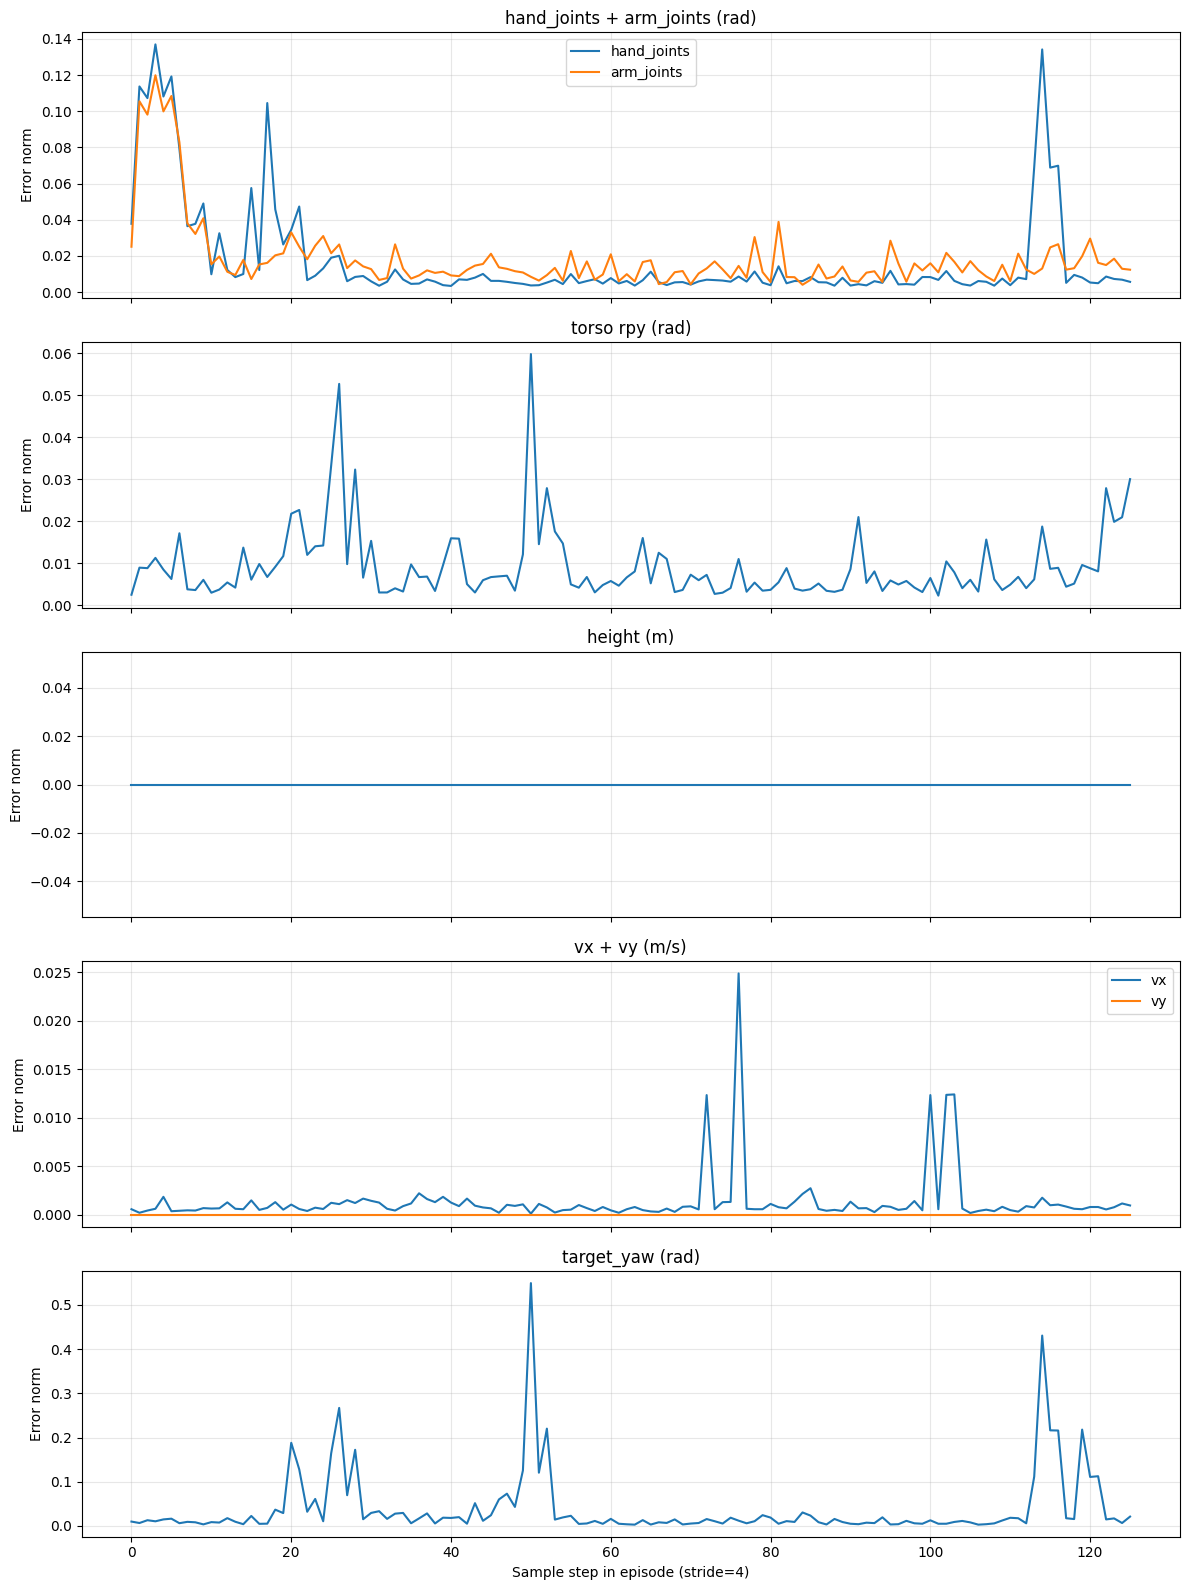

In [69]:
import matplotlib.pyplot as plt

# avg_action_errors_denormed_list: (T, 36)
group_slices = [14, 28, 31, 32, 33, 34, 35]
error_groups = np.split(avg_action_errors_denormed_list, group_slices, axis=-1)

# One scalar curve per semantic group
per_label_curves = [np.linalg.norm(group, axis=-1) for group in error_groups]
curve_map = dict(zip(labels_denormed, per_label_curves))

# Use target_dyaw as target_yaw for plotting name consistency
curve_map["target_yaw"] = curve_map.get("target_yaw", curve_map.get("target_dyaw"))

plot_groups = [
    ("hand_joints + arm_joints (rad)", ["hand_joints", "arm_joints"]),
    ("torso rpy (rad)", ["rpy"]),
    ("height (m)", ["height"]),
    ("vx + vy (m/s)", ["vx", "vy"]),
    ("target_yaw (rad)", ["target_yaw"]),
]

fig, axes = plt.subplots(5, 1, figsize=(12, 16), sharex=True)

for ax, (title, keys) in zip(axes, plot_groups):
    for key in keys:
        curve = curve_map.get(key)
        if curve is None:
            continue
        ax.plot(curve, label=key)
    ax.set_title(title)
    ax.set_ylabel("Error norm")
    ax.grid(True, alpha=0.3)
    if len(keys) > 1:
        ax.legend()

axes[-1].set_xlabel("Sample step in episode (stride=4)")
plt.tight_layout()
plt.show()